In [86]:
import pandas as pd
import numpy as np
# To train and test data
from sklearn.model_selection import train_test_split
# To manage categorical features
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
# To define the models
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
# To measure model quality
from sklearn.metrics import mean_absolute_error, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# Visualise
import matplotlib.pyplot as plt
# Save trained model
import pickle

In [2]:
# Load the data
path = '../data/csv/porsche_data.csv'
df = pd.read_csv(path)
## Drop rows with empty columns
df.dropna(inplace=True)
df

,id,model_year,model_type,mileage,condition,price_now,price_3_years_ago,appreciated,image_paths,seller_description,source
0,p00001,1987.0,944,132000.0,Fair,16250.0,13944,yes,"[""project/data/images/p00001_image_1.jpg"", ""pr...",project/data/descriptions/p00001_seller_descri...,https://bringatrailer.com/listing/1987-porsche...
1,p00002,1970.0,911,93000.0,Fair,84050.0,76500,yes,"[""project/data/images/p00002_image_1.jpg"", ""pr...",project/data/descriptions/p00002_seller_descri...,https://bringatrailer.com/listing/1970-porsche...
2,p00003,1970.0,911,2.0,Excellent,500000.0,73000,yes,"[""project/data/images/p00003_image_1.jpg"", ""pr...",project/data/descriptions/p00003_seller_descri...,https://bringatrailer.com/listing/1966-porsche...
3,p00004,2018.0,911,1200.0,Fair,435000.0,322000,yes,"[""project/data/images/p00004_image_1.jpg"", ""pr...",project/data/descriptions/p00004_seller_descri...,https://bringatrailer.com/listing/2018-porsche...
4,p00005,1965.0,356,148.0,Excellent,755000.0,4500,yes,"[""project/data/images/p00005_image_1.jpg"", ""pr...",project/data/descriptions/p00005_seller_descri...,https://bringatrailer.com/listing/1965-porsche...
...,...,...,...,...,...,...,...,...,...,...,...
1374,p01375,1976.0,911,59000.0,Fair,76000.0,35500,yes,"[""project/data/images/p01375_image_1.jpg"", ""pr...",project/data/descriptions/p01375_seller_descri...,https://bringatrailer.com/listing/1976-porsche...
1375,p01376,2023.0,Cayman,4600.0,Fair,186000.0,130000,yes,"[""project/data/images/p01376_image_1.jpg"", ""pr...",project/data/descriptions/p01376_seller_descri...,https://bringatrailer.com/listing/2023-porsche...
1376,p01377,1961.0,356,17000.0,Fair,148000.0,81000,yes,"[""project/data/images/p01377_image_1.jpg"", ""pr...",project/data/descriptions/p01377_seller_descri...,https://bringatrailer.com/listing/1961-porsche...
1377,p01378,1988.0,911,100000.0,Fair,80000.0,44750,yes,"[""project/data/images/p01378_image_1.jpg"", ""pr...",project/data/descriptions/p01378_seller_descri...,https://bringatrailer.com/listing/1988-porsche...


In [17]:
# Select data X and y
X_list = ['model_year', 'model_type', 'mileage', 'condition', 'price_now', 'price_3_years_ago']
X = df[X_list]
y = df.appreciated

# Label encode yes/no in col 'appreciated'
le = LabelEncoder()
y = le.fit_transform(y)

In [4]:
# Clean the data
## Manage categorical values - One-hot encoding
object_cols = [col for col in X.columns                                 # get all columns that have categorical data
               if X[col].dtype == 'object']
oh = OneHotEncoder(handle_unknown='ignore', sparse_output=False)                     # define encoder
cols_oh = pd.DataFrame(oh.fit_transform(X[object_cols]))                             # add new OH columns to the X df

## Ensure new X dataframe has the same col names
cols_oh.index = X.index

## Get numerical columns in X dataframes
num_X = X.drop(object_cols, axis=1)

## Combine categorical and numerical columns in X dataframes
X_oh = pd.concat([num_X, cols_oh], axis=1)

## Ensure all column names are strings
X_oh.columns = X_oh.columns.astype(str)
X_oh

,model_year,mileage,price_now,0,1,2,3,4,5,6,...,555,556,557,558,559,560,561,562,563,564
0,1987.0,132000.0,16250.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1970.0,93000.0,84050.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1970.0,2.0,500000.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2018.0,1200.0,435000.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1965.0,148.0,755000.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1374,1976.0,59000.0,76000.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1375,2023.0,4600.0,186000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1376,1961.0,17000.0,148000.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1377,1988.0,100000.0,80000.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
# Train
train_X, val_X, train_y, val_y = train_test_split(X_oh, y, random_state=0)
train_X

,model_year,mileage,price_now,0,1,2,3,4,5,6,...,555,556,557,558,559,560,561,562,563,564
365,2023.0,17000.0,148000.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
197,1991.0,82000.0,128964.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1337,2018.0,174.0,560000.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
722,1998.0,59000.0,146000.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
748,1976.0,75000.0,30250.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
854,1983.0,75000.0,68500.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
934,2024.0,4700.0,97000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1363,2000.0,36000.0,47500.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
617,2003.0,97000.0,47000.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [59]:
# Choose best max number of leaf nodes in Random Forest
def get_mae(train_X, val_X, train_y, val_y, model):
    model.fit(train_X, train_y)
    preds = model.predict(val_X)
    mae = mean_absolute_error(val_y, preds)
    return mae

model1 = RandomForestRegressor()
print('Random Forest')
for max_nodes in [5, 50, 500, 5000, 50000]:
    nodes_mae1 = get_mae(train_X, val_X, train_y, val_y, model=model1)
    print(f'Max leaf nodes: {max_nodes}\t\tMAE: {nodes_mae1}')

Random Forest
Max leaf nodes: 5		MAE: 0.27435064935064934
Max leaf nodes: 50		MAE: 0.27428571428571424
Max leaf nodes: 500		MAE: 0.27935064935064935
Max leaf nodes: 5000		MAE: 0.2764285714285714
Max leaf nodes: 50000		MAE: 0.2738961038961039


In [58]:
# Random Forest: Define and fit the model
model1 = RandomForestRegressor(max_leaf_nodes=500)
model1.fit(train_X, train_y)

# Inference
preds1 = model1.predict(val_X)

print(f'Random Forest accuracy: {round(model1.score(val_X, val_y)*100, 2)}%')

Random Forest accuracy: 43.44%


In [51]:
# Logistic Regression: Define and fit the model
model2 = LogisticRegression(max_iter=10000)
model2.fit(train_X, train_y)

# Inference
preds2 = model2.predict(val_X)

print(f'Logistic Regression accuracy: {round(model2.score(val_X, val_y)*100, 2)}%')

Logistic Regression accuracy: 61.69%


In [70]:
# Evaluate model1 and model2
for name, model in [('Random Forest', model1), ('Logistic Regression', model2)]:
    pred_y = model.predict(val_X)
    # Convert inference/prediction made by Random Forest model to readable output
    if model == model1:
        pred_y = np.round(pred_y).astype(int)
    print(f'\n{name}\
            \n\tAccuracy: {round(accuracy_score(val_y, pred_y), 2)*100}%\
            \n\tPrecision: {round(precision_score(val_y, pred_y), 2)*100}%\
            \n\tRecall: {round(recall_score(val_y, pred_y), 2)*100}%\
            \n\tF1-score: {round(f1_score(val_y, pred_y), 2)*100}%')

print('\nThe best model is using the Random Forest Regressor.')


Random Forest            
	Accuracy: 78.0%            
	Precision: 75.0%            
	Recall: 83.0%            
	F1-score: 79.0%

Logistic Regression            
	Accuracy: 62.0%            
	Precision: 59.0%            
	Recall: 71.0%            
	F1-score: 64.0%

The best model is using the Random Forest Regressor.


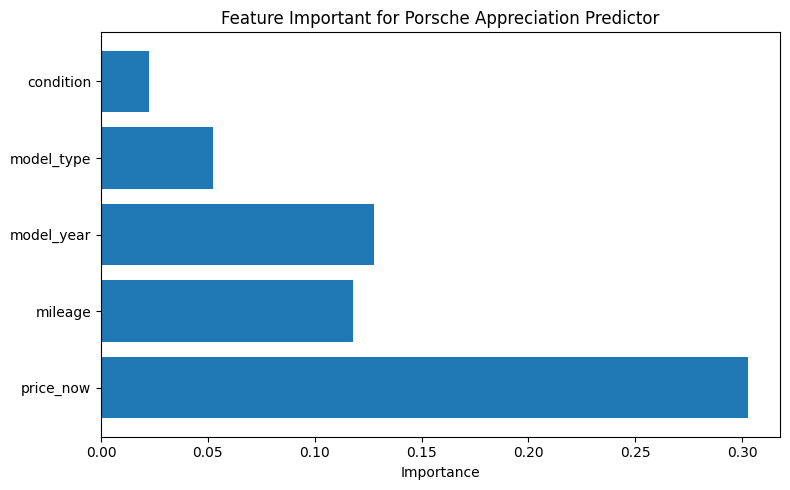

In [89]:
# Random Forest: Feature importance
importances = model1.feature_importances_
feature_names = train_X.columns.tolist()

# Get feature names from OH to identify which OH columns belong to which features
oh_feature_names = oh.get_feature_names_out(object_cols)

# Only show three features
desired_features = ['price_now', 'mileage', 'model_year', 'model_type']
filtered_importances = []
filtered_names = []

# Add numerical features
for feature in desired_features:
    if feature in feature_names:
        idx = feature_names.index(feature)
        filtered_importances.append(importances[idx])
        filtered_names.append(feature)

# Aggregate model_type and condition from their OH columns (num strings)
model_type_importance = 0
condition_importance = 0

# Better approach: Get indices of all OH columns in feature_names
for i, name in enumerate(feature_names):
    # Check if i is a OH column
    if str(name).isdigit():
        # Which feature does this OH belong to?
        oh_idx = int(name)
        if oh_idx < len(oh_feature_names):
            oh_feature_name = oh_feature_names[oh_idx]
            if oh_feature_name.startswith('model_type'):
                model_type_importance += importances[i]
            elif oh_feature_name.startswith('condition'):
                condition_importance += importances[i]

# Add aggregated categorical features
filtered_importances.append(model_type_importance)
filtered_names.append('model_type')
filtered_importances.append(condition_importance)
filtered_names.append('condition')

plt.figure(figsize=(8,5))
plt.barh(filtered_names, filtered_importances)
plt.xlabel('Importance')
plt.title('Feature Important for Porsche Appreciation Predictor')
plt.tight_layout()
plt.savefig('feature_importance.jpg', dpi=300)
plt.show()

In [90]:
# Save trained model
pickle.dump(model1, open('porsche_model.pkl', 'wb'))